In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

Extracting Dineutron Data:

In [2]:
import os
print("current working directory:", os.getcwd())
os.chdir("C:\\Users\\shing\\OneDrive\\EinR + ResearchPaper\\EinR\\Data")
print("files here:", os.listdir())


current working directory: c:\Users\shing\OneDrive\EinR + ResearchPaper\Research Paper
files here: ['dineutron_Zjn_tNorm3_evp.h5', 'nn_deuteron_spectrum.h5', 'nn_dineutron_spectrum.h5']


In [3]:
import h5py, numpy as np, matplotlib.pyplot as plt
filename = "nn_dineutron_spectrum.h5"
L = 48
by_Psq = {}

with h5py.File(filename, "r") as f:
    mN = f["mN/E0"][()]
    for gname, g in f.items():
        if gname == "mN":
            continue
        q1 = g["Psq_N1"][()][0]
        q2 = g["Psq_N2"][()][0]
        by_Psq.setdefault(q1, []).append(g["E_N1"][()])
        by_Psq.setdefault(q2, []).append(g["E_N2"][()])

Psq = np.array(sorted(by_Psq))
p2 = (2*np.pi/L)**2 * Psq
E = np.array([np.mean(by_Psq[q], axis=0) for q in Psq])
print(Psq)
print(p2)
print(E.shape)

[0 1 2 3 4]
[0.         0.01713473 0.03426946 0.05140419 0.06853892]
(5, 5001)


In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

rng = np.random.default_rng(1234)

filename = "nn_dineutron_spectrum.h5"
L = 48.0
 
punit = 2*np.pi/L
punit2 = punit**2


def boot_err(x):
    return np.std(x[1:], ddof=1)


def get_dE(g):
    for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
        if key in g:
            return np.array(g[key])
    raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


def get_irrep(name):
    return name.split("_Psq")[0]


def get_Psq_total(name):
    m = re.search(r"Psq(\d+)", name)
    if m is None:
        raise ValueError(f"Could not read total Psq from {name}")
    return int(m.group(1))


def get_level(name):
    m = re.search(r"level(\d+)", name)
    return int(m.group(1)) if m is not None else 0


def dvec_from_d2(d2):
    nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
    best = None
    for nx in range(nmax + 1):
        for ny in range(nmax + 1):
            for nz in range(nmax + 1):
                v = np.array([nx, ny, nz], dtype=int)
                if int(np.dot(v, v)) == int(d2):
                    cand = tuple(sorted(v))
                    if best is None or cand < best:
                        best = cand
    if best is None:
        raise ValueError(f"No integer momentum representative found for Psq={d2}")
    return np.array(best, dtype=int)


raw_levels = []

with h5py.File(filename, "r") as f:
    mN = np.array(f["mN/E0"])
    m = float(mN[0])

    for name, g in f.items():
        if name == "mN":
            continue

        irrep = get_irrep(name)
        Psq_tot = get_Psq_total(name)
        level_index = get_level(name)

        N1 = int(np.array(g["Psq_N1"])[0])
        N2 = int(np.array(g["Psq_N2"])[0])
        dE = get_dE(g)

        E1 = np.sqrt(mN**2 + punit2*N1)
        E2 = np.sqrt(mN**2 + punit2*N2)
        E_NN = dE + E1 + E2

        E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot)
        kstar2 = E_cm**2/4 - mN**2
        q2 = kstar2/punit2

        raw_levels.append({
            "name": name,
            "irrep": irrep,
            "Psq_tot": Psq_tot,
            "level_index": level_index,
            "pair": tuple(sorted((N1, N2))),
            "Ecm_boot": E_cm,
            "q2_boot": q2,
        })

raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))
print([r["Psq_tot"] for r in raw_levels])

print(raw_levels[0])
#range: lowest level and highest level, and add/subtract .05 in q^2/m^2 units
#.01 in q^2 units
print(m)

[0, 0, 1, 1, 2, 3, 4, 4]
{'name': 'A1g_Psq0_level0', 'irrep': 'A1g', 'Psq_tot': 0, 'level_index': 0, 'pair': (0, 0), 'Ecm_boot': array([1.40448019, 1.40578704, 1.40615159, ..., 1.40526527, 1.40456552,
       1.40507638], shape=(5001,)), 'q2_boot': array([-0.03629042, -0.0383827 , -0.0397186 , ..., -0.0102287 ,
       -0.03663671, -0.02511149], shape=(5001,))}
0.7026827020795523


In [5]:
Energy_list = []
for r in raw_levels:
    Energy_list.append(r['Ecm_boot'][0])



F-Function

In [6]:
import itertools
from scipy import special as sp

'''
Finite-volume function
'''

twoPi = 2.0 * np.pi


# Let us work with ideentical particles throughout
xi = 0.5 # symmetry factor

# sqrt with branch cut aligned on positive real axis
def mySqrt(z):
   return 1j * np.sqrt( -z )

# CM momentum
def q_cm(s):
    return 0.5 * mySqrt( s - 4.0 * float(m) **2 )

# Phase space factor
def phase_space(s):
    return xi * q_cm(s) / ( 8.0 * np.pi * np.sqrt(s) )

# inner product for two list (native)
def dot(A, B):
   return np.dot(A,B) #inner1d(A,B) #np.sum( A * B, axis=1)


def inner1d(A, B):
   return np.sum( A * B, axis=1)


# Function to generate 3-tuple "n = (nx,ny,nz)" list
# subject to the constraint nx^2 + ny^2 + nz^2 <= nShell^2,
# where "nShell" indicates the number of shells
def generateIntList( nShell ):
    intList = []
    rawList = np.array(np.arange(-nShell,nShell+1))
    for i in itertools.product(rawList,rawList,rawList):
        tmpList = np.array(i)
        if ( np.dot(tmpList,tmpList) <= nShell*nShell ):
            intList.append(tmpList)

    return np.asarray(intList)

# returns the unit vector of a vector "A"
def unit_vector( A ):
    if( all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime


# cutoff function (alpha input is dimensionless)
def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )

#
# KSS Zeta function for ell = m_ell = 0, given "qcm_sq", total momentum "nP"
# This function is in units of L / 2pi, e.g. m1 -> m1 * L / (2 * pi).
#

# Finite volume function F, given Ecm (units of mass), nP, alpha (dimensionless), and L (units of mass)
# MUST call generateIntList first and use global intList from its output
#
# Note: We chose to have Ecm as input rather than E for convenience in plotting/ pole finding. Coding it the other way works too,
# we are just saving ourselves a couple transformations which are not needed for our purposes.
#
def F_function( Ecm, nP, alpha, L):
    P = twoPi * nP / L                               # P = (2*pi/L)* nP
    P_sq = np.dot(P,P)                              # P^2
    E = np.sqrt( Ecm**2 + P_sq )                    # compute E given Ecm and P
    s = Ecm**2
    eps = 1e-16
    qcm = q_cm(s+1j*eps)
    qcm_sq = qcm**2
    rho = phase_space(s+1j*eps)
    beta = P/E                                      # boost velocity

    m_sq = m**2

    k = (twoPi / L) * intList
    omega = np.sqrt( m_sq + inner1d(k,k) )
    omega_cm, k_cm = lorentzBoost( omega, k, beta )
    tmp = cutoff( qcm_sq, inner1d(k_cm,k_cm), alpha, L ) * omega_cm / omega
    tmp = tmp / ( qcm_sq - inner1d(k_cm,k_cm ) )
    sum0 = ( xi / (2.0 * Ecm * L**3) ) * np.sum( tmp )

    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    z   = np.sqrt( alpha ) * qcm
    integral = ( xi / (4.0 * np.pi**2 * Ecm )) * ( ( np.sqrt( 0.25 * np.pi / alpha ) ) * np.exp( alpha * qcm_sq ) - 0.5 * np.pi * qcm * sp.erfi( z ) )

    return  1j * rho + sum0.real + integral # taking real part of sum to remove imaginary artifact at threshold



Various Constants

In [7]:
nShell = 15
alpha = 0.125

intList = generateIntList( nShell )

pole_gap = 3e-4

# Psq_to_nP = {
#     0:np.array([0,0,0]),
#     1:np.array([0,0,1]),
#     2:np.array([0,1,1]),
#     3:np.array([1,1,1]),
#     4:np.array([0,0,2])
# }

present_Psq = sorted(set(lvl["Psq_tot"] for lvl in raw_levels))
Psq_to_nP = {psq: dvec_from_d2(psq) for psq in present_Psq}

L_values = [48]

E_min = np.min(Energy_list)-0.01
E_max = np.max(Energy_list)+0.01

q2_min = (E_min/2)**2 - m**2
q2_max = (E_max/2)**2 - m**2
q_star_sq_grid = np.linspace(q2_min, q2_max,2500)

Ecm_grid = 2*np.sqrt(q_star_sq_grid + m**2)

a_r_Values = np.array([
    [-0.18,0.32,0.05],     # virtual state  -> matches Fig. 3
    [ 0.18,0.0,0.0],   # shallow bound state -> matches Fig. 5
])


Fake Energy Levels 

In [8]:
pole_cache = {}


def free_particle_poles(nP, L, m, E_min, E_max, maxShell=15):
    punit_ = 2*np.pi/L
    nP_arr = np.array(nP, dtype=float)
    Pvec = punit_*nP_arr
    P2_ = np.dot(Pvec, Pvec)
    levels = []
    for i in range(-maxShell, maxShell+1):
        for j in range(-maxShell, maxShell+1):
            for k in range(-maxShell, maxShell+1):
                n1 = np.array([i,j,k]); n2 = nP_arr - n1
                p1, p2 = punit_*n1, punit_*n2
                E_lab = float(np.sqrt(p1@p1+m**2) + np.sqrt(p2@p2+m**2))
                E_cm_sq = E_lab**2 - P2_
                if E_cm_sq <= 0:
                    continue
                E_cm = np.sqrt(E_cm_sq)
                if E_min - 0.05 < E_cm < E_max + 0.05:
                    levels.append(E_cm)
    return np.unique(np.round(levels, 10))


def free_particle_poles_cached(nP, L, m, E_min, E_max, maxShell=15):
    key = (tuple(nP), L, m, E_min, E_max, maxShell)
    if key not in pole_cache:
        raw = free_particle_poles(nP, L, m, E_min, E_max, maxShell)

        if len(raw) == 0:
            pole_cache[key] = raw
        else:
            unique = [raw[0]]
            for p in raw[1:]:
                if abs(p - unique[-1]) > 1e-5:
                    unique.append(p)
            pole_cache[key] = np.array(unique, dtype=float)
    return pole_cache[key]



In [9]:
def mySqrt_vectorized(z):
    z = np.asarray(z, dtype=complex)
    return 1j * np.sqrt(-z)

def q_cm_vectorized(s):
    return 0.5 * mySqrt_vectorized(s - 4.0 * m**2)

def M_using_a_r(Ecm, a, r, p4):
    s = Ecm**2
    qcm = q_cm_vectorized(s)
    effective_range = a + r * (qcm**2) + p4 * (qcm**4)
    return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))

# def M_using_a_r(Ecm, a, r): 
#     s = Ecm**2
#     qcm = q_cm_vectorized(s)
#     effective_range = (-1/a) + 0.5 * r * (qcm**2)
#     return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))

# def quantization_condition(Ecm, a, r, nP,L):
#     # eps = 1e-16
#     # s = Ecm**2 + 1j*eps
#     # qCotDelta = -1/a + 0.5*r*q_cm(s)**2
#     # Kinverse = xi * qCotDelta / (8*np.pi*Ecm)   <----- 2 ways to implment quantization condition. Comment out 1
#     # Fpv = F_function(Ecm, nP, alpha, L).real   
#     # return (Kinverse + Fpv).real
   
   
#     FValues = F_function(Ecm,nP,alpha,L)
#     MValues = M_using_a_r(Ecm,a,r)                 #<----- 2 ways to implment quantization condition. Comment out 1
#     return np.real(1/MValues + FValues)

In [10]:


# def find_zeros_in_grid(quantization_values, energies, poles,Psq):
#     zeros = []
#     for i in range(len(energies) - 1):
#         f1, f2 = quantization_values[i], quantization_values[i+1]
#         e1, e2 = energies[i], energies[i+1]
#         if not (np.isfinite(f1) and np.isfinite(f2)):
#             continue
#         if np.sign(f1) == np.sign(f2):
#             continue
#         if np.any((poles >= e1) & (poles <= e2)):
#             continue   
#         slope = (f2 - f1) / (e2 - e1)

#         root = e1 - f1/slope
#         if np.any(np.abs(root - poles) < pole_gap):
#             continue


#         zeros.append(e1 - f1/slope)
    # return np.array(zeros)

def find_zeros_in_grid(quantization_values, energies, poles, Psq):
    f1, f2 = quantization_values[:-1], quantization_values[1:]
    e1, e2 = energies[:-1], energies[1:]

    mask = np.isfinite(f1) & np.isfinite(f2) & (np.sign(f1) != np.sign(f2))

    if len(poles) > 0 and mask.any():
        idxs = np.where(mask)[0]
        bracket_has_pole = np.zeros(len(idxs), dtype=bool)
        for p in poles:                       # loop over poles (small, ~5-15), not grid points
            bracket_has_pole |= (p >= e1[idxs]) & (p <= e2[idxs])
        mask[idxs] &= ~bracket_has_pole

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.array([])

    slope = (f2[idx] - f1[idx]) / (e2[idx] - e1[idx])
    roots = e1[idx] - f1[idx]/slope

    if len(poles) > 0 and len(roots) > 0:
        dists = np.abs(roots[:, None] - poles[None, :])
        keep = np.all(dists >= pole_gap, axis=1)
        roots = roots[keep]

    return roots


In [11]:
F_by_Psq = {}
for L in L_values:
    for Psq_tot, nP in Psq_to_nP.items():
        F_by_Psq[(L, Psq_tot)] = np.array([
            F_function(Ecm, nP, alpha, L) for Ecm in Ecm_grid
        ])

#test code, not ever used
# def spectrum_from_ar(a, r, L, Psq_tot):
#     Q = quantization_grid(a, r, L, Psq_tot)
#     poles = free_particle_poles_cached(Psq_to_nP[Psq_tot], L, m)
#     return find_zeros_in_grid(Q, Ecm_grid, poles, Psq_tot)

def quantization_grid(a, r, p4, L, Psq_tot):
    M_values = M_using_a_r(Ecm_grid, a, r, p4)
    F_values = F_by_Psq[(L, Psq_tot)]
    return np.real(1.0 / M_values + F_values)

In [12]:

sigma_E = 0.010 #the uncertainty, acts as noise
rng = np.random.default_rng()


def generate_spectrum(i, L_values, Psq_to_nP, E_min, E_max, sigma_E):
    rows = [] #the "observed" data, is noisy
    true_rows = [] #the actual data values, to check with.only exists for valdiation
    a,r = a_r_Values[i]

    for L in L_values:
        for Psq, nP in Psq_to_nP.items():
            Q = quantization_grid(a, r, L, Psq)
            poles = free_particle_poles_cached(nP, L, m, E_min, E_max)
            E_true_levels = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)

            for level_index, E_true in enumerate(E_true_levels):
                E_obs = E_true + rng.normal(0.0, sigma_E)       
                row = {
                    "L": float(L),
                    "Psq": Psq,
                    "level_index": level_index,
                    "E_true": float(E_true),
                    "E_obs": float(E_obs),
                    "dE": sigma_E,
                }

                rows.append(row)
                true_rows.append(row.copy())

    data = rows
    print(f"generated {len(data)} finite-volume levels across {len(L_values)} volumes and {len(Psq_to_nP.keys())} frames")
    return data 

In [13]:
def rows_from_raw_levels(raw_levels, L):
    rows = []
    for lvl in raw_levels:
        Ecm_boot = lvl["Ecm_boot"]
        rows.append({
            "L": float(L),
            "Psq": lvl["Psq_tot"],
            "level_index": lvl["level_index"],
            "E_obs": float(Ecm_boot[0]),      # or Ecm_boot.mean()
            "dE": float(boot_err(Ecm_boot)),  # np.std(Ecm_boot[1:], ddof=1)
        })
    return rows

data_real = rows_from_raw_levels(raw_levels, L=48)
print(data_real)

[{'L': 48.0, 'Psq': 0, 'level_index': 0, 'E_obs': 1.404480193149725, 'dE': 0.0007506551218981072}, {'L': 48.0, 'Psq': 0, 'level_index': 1, 'E_obs': 1.427387430256371, 'dE': 0.0007935596115245533}, {'L': 48.0, 'Psq': 1, 'level_index': 0, 'E_obs': 1.4097814949159677, 'dE': 0.0007684675439241838}, {'L': 48.0, 'Psq': 1, 'level_index': 1, 'E_obs': 1.4333221966427518, 'dE': 0.0008761569775460531}, {'L': 48.0, 'Psq': 2, 'level_index': 0, 'E_obs': 1.4147421255240087, 'dE': 0.0008041403937385471}, {'L': 48.0, 'Psq': 3, 'level_index': 0, 'E_obs': 1.4199751076807943, 'dE': 0.0008105941934642061}, {'L': 48.0, 'Psq': 4, 'level_index': 0, 'E_obs': 1.4044221450218684, 'dE': 0.0007675244981894147}, {'L': 48.0, 'Psq': 4, 'level_index': 1, 'E_obs': 1.4271811314910883, 'dE': 0.00084483133111793}]


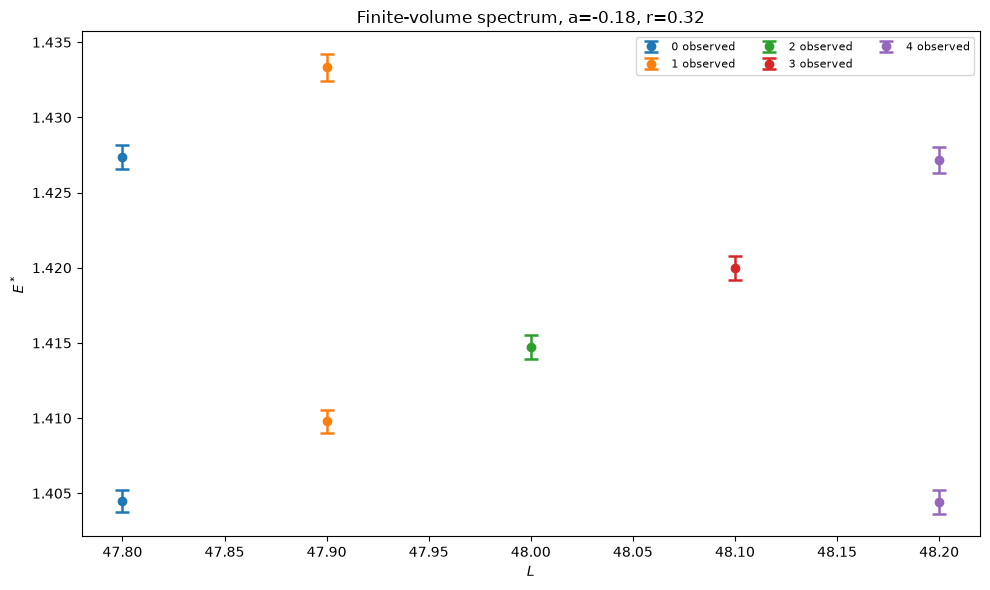

In [14]:
Psq_offsets = {0: -0.2, 1: -0.1, 2: 0.0, 3: 0.1, 4: 0.2}

def plot_spectrum(level_rows, i, include_observed=True, include_true=False, predicted_rows=None):
    plt.figure(figsize=(10, 6))
    for Psq in Psq_to_nP.keys():
        offset = Psq_offsets[Psq]
        rows_frame = [r for r in level_rows if r["Psq"] == Psq]

        if include_observed:
            x_obs = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_obs = np.array([r["E_obs"] for r in rows_frame], dtype=float)
            yerr = np.array([r["dE"] for r in rows_frame], dtype=float)

            plt.errorbar(
                x_obs,
                y_obs,
                yerr=yerr,
                fmt="o",
                markersize=6,
                capsize=5,
                capthick=1.8,
                elinewidth=1.8,
                linewidth=0,
                label=f"{Psq} observed",
                zorder=5,
            )

        if include_true:
            x_true = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_true = np.array([r["E_true"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_true,
                y_true,
                marker="_",
                s=180,
                linewidths=2.8,
                label=f"{Psq} true",
                zorder=4,
            )

    if predicted_rows is not None:
        for Psq in Psq_to_nP.keys():
            offset = Psq_offsets[Psq]
            rows_frame = [r for r in predicted_rows if r["Psq"] == Psq]
            x_pred = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_pred = np.array([r["E_pred"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_pred,
                y_pred,
                marker="x",
                s=70,
                linewidths=2.2,
                label=f"{Psq} GP",
                zorder=6,
            )

    # plt.xticks(L_values, [str(int(L)) for L in L_values])
    plt.xlabel(r"$L$")
    plt.ylabel(r"$E^*$")
    plt.title(f"Finite-volume spectrum, a={a_r_Values[i][0]}, r={a_r_Values[i][1]}")

    plt.legend(ncols=3, fontsize=8)
    plt.tight_layout()
    plt.show()


#plot_spectrum(data0, 0)
#plot_spectrum(data1, 1)
plot_spectrum(data_real, 0)


In [15]:
for i in range(len(data_real)):
    print(data_real[i]['E_obs'])

1.404480193149725
1.427387430256371
1.4097814949159677
1.4333221966427518
1.4147421255240087
1.4199751076807943
1.4044221450218684
1.4271811314910883


Gaussian Process Regression 

Covariance Matrix


In [16]:
def build_covariance(levels, key="q2_boot"):
    boot_matrix = np.array([lvl[key][1:] for lvl in levels]).T   # (n_boot, n_levels)
    obs = np.array([lvl[key][0] for lvl in levels])
    cov = np.cov(boot_matrix, rowvar=False, ddof=0)
    return obs, cov

q2_obs, covariance = build_covariance(raw_levels)
cov_inv = np.linalg.inv(covariance)
print(covariance)


[[1.98253195e-04 7.62044986e-05 8.65597619e-05 8.02616906e-05
  8.19648451e-05 8.33887916e-05 7.09859453e-05 8.11331276e-05]
 [7.62044986e-05 2.13864368e-04 8.78216578e-05 1.11997365e-04
  1.12663417e-04 8.79352677e-05 8.84680954e-05 1.01556953e-04]
 [8.65597619e-05 8.78216578e-05 1.81650879e-04 1.01760777e-04
  1.12972280e-04 9.39879251e-05 8.57652909e-05 9.60843853e-05]
 [8.02616906e-05 1.11997365e-04 1.01760777e-04 4.77786008e-04
  1.34442767e-04 1.03023886e-04 9.54373630e-05 1.19922127e-04]
 [8.19648451e-05 1.12663417e-04 1.12972280e-04 1.34442767e-04
  2.37765359e-04 1.06353903e-04 1.07032474e-04 1.13990571e-04]
 [8.33887916e-05 8.79352677e-05 9.39879251e-05 1.03023886e-04
  1.06353903e-04 2.61628512e-04 7.89959487e-05 1.01570213e-04]
 [7.09859453e-05 8.84680954e-05 8.57652909e-05 9.54373630e-05
  1.07032474e-04 7.89959487e-05 1.50461797e-04 8.22353627e-05]
 [8.11331276e-05 1.01556953e-04 9.60843853e-05 1.19922127e-04
  1.13990571e-04 1.01570213e-04 8.22353627e-05 3.43029709e-04]]

In [17]:
def get_q_cot_delta(E,nP,alpha,L):
    F_pv = F_function(E, nP, alpha, L).real
    return -8 * np.pi * E * F_pv / xi


In [18]:
def combine_levels(Eboot, level_keys, groups, weights=None):
    """
    Combine multiple degenerate/matched levels into fewer inputs, averaging
    WITHIN each bootstrap replica so correlations are correctly propagated
    (matching Fig. 11's procedure: 'weights act on E_lab within each
    bootstrap replica before conversion').

    Eboot       : (N_boot, n_total) array, one row per bootstrap replica
    level_keys  : list of (L, Psq, level_index) matching Eboot's columns
    groups      : list of lists of column-indices to combine, e.g.
                  [[0, 1], [2], [3], [4, 5]]  -- indices 0&1 combined,
                  2 and 3 left alone, 4&5 combined
    weights     : optional list, one entry per group, giving per-member
                  weights (e.g. irrep dimension); None -> equal weights

    Returns:
        Eboot_combined : (N_boot, n_groups) reduced bootstrap ensemble
        Eobs_combined  : (n_groups,) combined central values
        CovE_combined  : (n_groups, n_groups) combined covariance matrix
        combined_labels: which original level_keys went into each new entry
    """
    N_boot = Eboot.shape[0]
    n_groups = len(groups)
    Eboot_combined = np.zeros((N_boot, n_groups))
    combined_labels = []

    for g, idxs in enumerate(groups):
        if weights is not None and weights[g] is not None:
            w = np.asarray(weights[g], dtype=float)
        else:
            w = np.ones(len(idxs))
        w = w / w.sum()
        Eboot_combined[:, g] = Eboot[:, idxs] @ w
        combined_labels.append(tuple(level_keys[i] for i in idxs))

    Eobs_combined = Eboot_combined.mean(axis=0)
    CovE_combined = np.cov(Eboot_combined, rowvar=False, ddof=0)

    return Eboot_combined, Eobs_combined, CovE_combined, combined_labels

Building my own GP implementation 

Stage 1.
    - vector of knots
    - builds nxn kernel matrix, given hyperparamters
    - adds small jitter term

In [19]:
num_knots = 8 
knots = np.linspace(q2_min,q2_max,num_knots) # knots ->x

def RBC_kernel(x,y,sigma,length_scale): # kernel matrix 
    x=np.asarray(x).reshape(-1,1)
    y=np.asarray(y).reshape(-1,1)
    return sigma**2 * np.exp(-0.5 * (np.abs(x-y.T)**2) / length_scale**2)

def Matern_kernel(x, y, sigma, length_scale, nu=2.5):
    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(-1,1)
    r = np.sqrt(np.abs(x - y.T))
    if nu == 0.5:
        return sigma**2 * np.exp(-r / length_scale)
    elif nu == 1.5:
        return sigma**2 * (1 + np.sqrt(3) * r / length_scale) * np.exp(-np.sqrt(3) * r / length_scale)
    elif nu == 2.5:
        return sigma**2 * (1 + np.sqrt(5) * r / length_scale + 5 * r**2 / (3 * length_scale**2)) * np.exp(-np.sqrt(5) * r / length_scale)


def kernel_matrix(x, y, sigma, length_scale, kernel_func = RBC_kernel):
    k =  kernel_func(x, y, sigma, length_scale) + np.eye(num_knots) * 1e-8 
    sign, logdet = np.linalg.slogdet(k)
    if sign <= 0:
        raise np.linalg.LinAlgError("GP covariance is not positive definite")

    K_inv = np.linalg.inv(k)
    interp_grid = kernel_func(Ecm_grid, knots , sigma, length_scale) @ K_inv                        

    return k, K_inv, logdet, interp_grid



Stage 2.
    -

In [20]:
# def k_inv_Grid(Ecm, sigma, length_scale, f_values): #we are deliberately not using the covariance term
#     k, k_inv, logdet, interp_grid = kernel_matrix(knots,knots,sigma,length_scale)
#     k_inv_grid = interp_grid @ f_values
#     return k_inv_grid

def Kinv_Grid(Ecm, sigma, length_scale, f_values): #we are deliberately not using the covariance term
    k, k_inv, logdet, interp_grid = kernel_matrix(knots,knots,sigma,length_scale)
    Kinv_grid = interp_grid @ f_values
    return Kinv_grid


Stage 3:
Using GP curve in place of ERE in Luscher Quantization Formula

In [21]:
def find_Zeros_GPR(f_values, sigma, length_scale, L,Psq, Kinv_grid):
    Q = np.real(Kinv_grid + F_by_Psq[(L, Psq)])
    poles = free_particle_poles_cached(Psq_to_nP[Psq], L, m , E_min, E_max)
    zeros = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)
    return zeros


Stage 4

In [22]:
def build_observed_cache(data):
    """
    Group observed synthetic levels by (L, Psq) sector, once, so the
    likelihood function can look them up instantly on every MCMC call
    instead of re-filtering the full dataset each time.

    Returns:
        dict keyed by (L, Psq) -> {"E_obs": np.array, "dE": np.array}
    """
    cache = {}
    for row in data:
        key = (row["L"], row["Psq"])
        if key not in cache:
            cache[key] = {"E_obs": [], "dE": []}
        cache[key]["E_obs"].append(row["E_obs"])
        cache[key]["dE"].append(row["dE"])

    for key in cache:
        cache[key]["E_obs"] = np.array(cache[key]["E_obs"])
        cache[key]["dE"] = np.array(cache[key]["dE"])

    return cache


# observed_cache_0 = build_observed_cache(data0)   
# observed_cache_1 = build_observed_cache(data1)   

# observed_cache_0_cov = build_observed_cache(data0_cov)   # a=1, r=1
# observed_cache_1_cov = build_observed_cache(data1_cov)   # a=2, r=0

observed_cache_real = build_observed_cache(data_real)

def build_observed_data(levels, L):
    """
    levels: list of dicts (raw_levels, or the 8 combined deuteron levels),
            each with 'Psq_tot', 'level_index', and a 'q2_boot' bootstrap array
            (index 0 = central value, 1: = replicas).
    Returns a fixed-order channel dataset for use in log_likelihood.
    """
    obs, cov = build_covariance(levels, key="q2_boot")
    cov_inv = np.linalg.inv(cov)
    sector_keys = [(lvl["Psq_tot"], lvl["level_index"]) for lvl in levels]
    return {"L": L, "sector_keys": sector_keys, "obs": obs, "cov_inv": cov_inv}

observed_cache_dineutron = build_observed_data(raw_levels,48)

big_penalty = -1e6
count_mismatch_penalty = -25.0

def log_likelihood(f_values, sigma, length_scale, channel_data, Kinv):
    L = channel_data["L"]
    sector_keys = channel_data["sector_keys"]   # [(Psq, level_index), ...] fixed order
    obs = channel_data["obs"]                   # q*2, same order as sector_keys
    cov_inv = channel_data["cov_inv"]

    punit2 = (2 * np.pi / L) ** 2
    needed_Psq = sorted(set(psq for psq, _ in sector_keys))

    pred_by_sector = {}
    penalty = 0.0
    for Psq in needed_Psq:
        E_pred_arr = np.sort(find_Zeros_GPR(f_values, sigma, length_scale, L, Psq, Kinv))
        pred_by_sector[Psq] = E_pred_arr

        n_needed = sum(1 for psq, _ in sector_keys if psq == Psq)
        penalty += count_mismatch_penalty * abs(len(E_pred_arr) - n_needed)

    pred = np.empty_like(obs)
    for i, (Psq, level_index) in enumerate(sector_keys):
        E_pred_arr = pred_by_sector[Psq]
        if level_index >= len(E_pred_arr):
            # can't build a complete residual vector this step — bail with penalty
            return big_penalty + penalty, np.inf
        E_pred = E_pred_arr[level_index]
        pred[i] = ((E_pred / 2) ** 2 - m**2) / punit2   # match q2_boot's units
        # print(np.abs(pred[i]-obs))
    delta = pred - obs
    chi_squared = delta @ cov_inv @ delta
    return -0.5 * chi_squared + penalty, chi_squared
    

Stage 5:

In [23]:
def log_prior(f_values, sigma, length_scale):
    C, C_inv, logdet, _ = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior = -0.5 * f_values.T @ C_inv @ f_values - 0.5 * logdet - (num_knots / 2) * np.log(2 * np.pi)
    return log_prior

knot_spacing = (q2_max - q2_min) / (num_knots -1)
sigma_min, sigma_max = 0.001, 0.05
lc_min, lc_max = 0.01, 1.0

def log_hyperprior(sigma, length_scale):
    if not (sigma_min <= sigma <= sigma_max and lc_min <= length_scale <= lc_max):
        return -np.inf
    return -np.log(sigma_max - sigma_min) - np.log(lc_max - lc_min)

def log_posterior(f_values, sigma, length_scale, observed_cache):
    '''
    log_hyperprior_val = log_hyperprior(sigma, length_scale)
    if not np.isfinite(log_hyperprior_val):
        return -np.inf
    log_prior_val = log_prior(f_values, sigma, length_scale)
    log_likelihood_val = log_likelihood(f_values, sigma, length_scale, observed_cache)
    '''
    C, C_inv, logdet, interp_grid = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior_val = -0.5 * f_values.T @ C_inv @ f_values - 0.5*logdet - 0.5*num_knots *np.log(2*np.pi)

    Kinv = Kinv_Grid(Ecm_grid, sigma, length_scale, f_values)
    log_likelihood_val, chi_squared = log_likelihood(f_values, sigma, length_scale, observed_cache,Kinv)

    log_hyperprior_val = log_hyperprior(sigma, length_scale)

    return log_prior_val + log_likelihood_val + log_hyperprior_val

def posterior_components(f_values, sigma, length_scale, observed_cache):        
    C, C_inv, logdet, interp_grid = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior_val = -0.5 * f_values.T @ C_inv @ f_values - 0.5*logdet - 0.5*num_knots *np.log(2*np.pi)

    Kinv = Kinv_Grid(Ecm_grid, sigma, length_scale, f_values)
    log_likelihood_val, chi_squared = log_likelihood(f_values, sigma, length_scale, observed_cache, Kinv)

    log_hyperprior_val = log_hyperprior(sigma, length_scale)

    return log_prior_val, log_likelihood_val, log_hyperprior_val, chi_squared

Stage 6(single chain)

In [24]:
import numpy as np
rng = np.random.default_rng()

move_types = ["knot", "all_knots", "log_length_scale", "log_sigma"]


def propose_new_step(current_state, step_size):
    f_values, sigma, length_scale = current_state
    move = rng.random()
    
    if move < 0.4:
        k = rng.integers(1, len(f_values))
        f_copy = f_values.copy()
        f_copy[k] += step_size["knot"] * rng.normal()
        return (f_copy, sigma, length_scale),0.0,"knot"

    elif move < 0.7:
        f_new = f_values + step_size["all_knots"] * rng.normal(size=len(f_values))
        return (f_new, sigma, length_scale), 0.0,"all_knots"

    elif move < 0.9:
        log_length_scale_new = np.log(length_scale) + step_size["log_length_scale"] * rng.normal()
        length_scale_new = np.exp(log_length_scale_new)
        log_q_correction = np.log(length_scale_new) - np.log(length_scale)   # Hastings correction
        return (f_values, sigma, length_scale_new), log_q_correction,"log_length_scale"

    else:
        # random walk in log(sigma)
        log_sigma_new = np.log(sigma) + step_size["log_sigma"] * rng.normal()
        sigma_new = np.exp(log_sigma_new)
        log_q_correction = np.log(sigma_new) - np.log(sigma)
        return (f_values, sigma_new, length_scale), log_q_correction, "log_sigma"

def acceptance_step(current_state, log_posterior_current, log_posterior_function, step_sizes):
    proposed_state, log_q_correction, type = propose_new_step(current_state, step_sizes)
    log_posterior_proposed = log_posterior_function(*proposed_state)

    log_ratio = log_posterior_proposed - log_posterior_current + log_q_correction
    if np.log(rng.random()) < log_ratio:
        return proposed_state, log_posterior_proposed, True, type
    else:
        return current_state, log_posterior_current, False, type


In [25]:
def single_chain_mcmc(observed_cache, n_steps, burn_in):

    best_state, best_log_posterior = None, -np.inf

    accepted_by_type = {type: 0 for type in move_types}
    proposed_by_type = {type: 0 for type in move_types}

    window = 1000
    window_acc = {type: [] for type in move_types}
    window_prop = {type: 0 for type in move_types}
    window_accepted = {type: 0 for type in move_types}

    thin = 5

    samples = []
    log_post_history = []

    n_accepted = 0

    step_sizes = {
        "knot": 0.016,       
        "all_knots": 0.0025,  
        "log_length_scale": 0.022,    
        "log_sigma": 0.80}

    for attempt in range(20):
        f0 = 0.3 * rng.normal(0,1,num_knots)
        sigma0 = rng.uniform(sigma_min, sigma_max)
        length_scale0 = rng.uniform(lc_min, lc_max)
        log_post = log_posterior(f0, sigma0, length_scale0, observed_cache)
        if log_post > best_log_posterior:
            best_state, best_log_posterior = (f0, sigma0, length_scale0), log_post
        state = best_state
        log_post_current = best_log_posterior

    for step in range(n_steps):
        state, log_post_current, accepted, move_type = acceptance_step(
            state, log_post_current, 
            lambda f,s,l: log_posterior(f,s,l,observed_cache),
            step_sizes)
        if log_post_current > best_log_posterior:
            best_state, best_log_posterior = state, log_post_current

        log_post_history.append(log_post_current)


        recomputed = log_posterior(*state, observed_cache)
        if not np.isclose(log_post_current, recomputed, atol=1e-6):
            print(f"MISMATCH at step {step}: tracked={log_post_current:.4f}, recomputed={recomputed:.4f}")
        
        window_prop[move_type] += 1
        if accepted:
            window_accepted[move_type] += 1

        if step >= burn_in:
            proposed_by_type[move_type] += 1
            if accepted:
                accepted_by_type[move_type] += 1

        if (step + 1) % window == 0:
            for type in move_types:
                rate = window_accepted[type] / window_prop[type] if window_prop[type] > 0 else float('nan')
                window_acc[type].append(rate)
            window_prop = {type: 0 for type in move_types}
            window_accepted = {type: 0 for type in move_types}

        n_accepted += int(accepted)
        if step >= burn_in and step % thin == 0:
            samples.append(state)

        if (step+1) % 1000 == 0:
            acceptance_rate = n_accepted / (step+1)
            print(f"Step {step+1}/{n_steps}, acceptance rate: {acceptance_rate:.3f}")
    return samples, log_post_history, best_state, best_log_posterior, accepted_by_type, proposed_by_type, window_acc

In [26]:
# single_samples, single_history, single_best_state, single_best_post, single_accepted_by_type, single_proposed_by_type, single_window_acc = single_chain_mcmc(observed_cache_0, n_steps=3000, burn_in=2000)  


In [27]:
# print(single_proposed_by_type)

Covariance Matrix

det[K^-1 + F] = 0

Stage 6: Multi Chain:

In [28]:
betas = np.array([0.0, 0.02, 0.04, 0.08, 0.15, 0.25, 0.4, 0.6, 0.8, 1.0])
n_chains = len(betas)
best_chi_squared = np.inf

def log_tempered_target(f_knots, sigma, length_scale, beta, observed_cache):
    logprior, loglike, loghyper, chi_squared = posterior_components(f_knots, sigma, length_scale, observed_cache)
    logpost = loglike+logprior+loghyper
    if not np.isfinite(logpost):
        return -np.inf, loglike, logprior, chi_squared
    return beta*loglike + logprior + loghyper, loglike, logprior, chi_squared #loghyper might be removable, but we keep it for now to be safe.


def initialize_chains(observed_cache):
    chains_state = []
    chains_logtarget = []
    for c in range(n_chains):
        best_state, best_posterior = None, -np.inf
        for attempt in range(20):
            f0 = 0.3*rng.normal(0,1,num_knots)
            sigma0 = rng.uniform(sigma_min, sigma_max)
            ell0 = rng.uniform(lc_min, lc_max)
            posterior, _ , _ , _ = log_tempered_target(f0, sigma0, ell0, betas[c], observed_cache)
            if posterior > best_posterior:
                best_state, best_posterior = (f0, sigma0, ell0), posterior
        chains_state.append(best_state)
        chains_logtarget.append(best_posterior)
    return chains_state, chains_logtarget

def chain_step(chain_state, chain_logtarget, beta, step_sizes, observed_cache):
    global best_chi_squared
    proposed_state, log_q_correction, move_type = propose_new_step(chain_state, step_sizes)
    proposed_val, loglike, logprior, chi_squared = log_tempered_target(*proposed_state, beta, observed_cache)

    log_ratio = proposed_val - chain_logtarget + log_q_correction

    if(np.log(rng.random()) < log_ratio):
        if(chi_squared < best_chi_squared):
            best_chi_squared = chi_squared
        return proposed_state, proposed_val, True, move_type
    else:
        
        return chain_state, chain_logtarget, False, move_type

def try_swap(c, chains_state, chains_logtarget, betas, observed_cache):
    beta_a, beta_b = betas[c], betas[c+1]
    _, loglike_a, logprior_a, _ = log_tempered_target(*chains_state[c], beta_a, observed_cache)
    _, loglike_b, logprior_b, _ = log_tempered_target(*chains_state[c+1], beta_b, observed_cache)

    log_swap_ratio = (beta_a - beta_b) * (loglike_b - loglike_a)
    if(np.log(rng.random())) < log_swap_ratio:
        chains_state[c], chains_state[c+1] = chains_state[c+1], chains_state[c]
        chains_logtarget[c], _, _, _ = log_tempered_target(*chains_state[c], beta_a, observed_cache)
        chains_logtarget[c+1], _, _, _ = log_tempered_target(*chains_state[c+1], beta_b, observed_cache)
        return True
    return False

In [29]:
def run_parallel_tempering(observed_cache, n_steps, burn_in):
    cold = n_chains - 1
    thin = 5
    swap_every = 10

    multi_chain_sizes = {
        "knot": 0.016,       
        "all_knots": 0.0025,  
        "log_length_scale": 0.022,    
        "log_sigma": 0.80}

    samples = []
    swap_attempts = np.zeros(n_chains-1)
    swap_accepts = np.zeros(n_chains-1)
    cold_log_post_history = []
    # chi_squared_history = []
    cold_accepted_by_type = {t: 0 for t in move_types}
    cold_proposed_by_type = {t: 0 for t in move_types}
    best_cold_state, best_cold_logpost = None, -np.inf

    chains_state, chains_logtarget = initialize_chains(observed_cache)

    for step in range(n_steps):
        for c in range(n_chains):
            chains_state[c], chains_logtarget[c], accepted, move_type = chain_step(
                chains_state[c], chains_logtarget[c], betas[c], multi_chain_sizes, observed_cache
            )

            if c == cold:
                cold_log_post_history.append(chains_logtarget[c])
                if chains_logtarget[c] > best_cold_logpost:
                        best_cold_state, best_cold_logpost = chains_state[c], chains_logtarget[c]
                if step >= burn_in:
                    cold_proposed_by_type[move_type] += 1
                    if accepted:
                        cold_accepted_by_type[move_type] += 1

        if((step+1) % swap_every == 0):   
            for c in range(n_chains - 1):
                swap_attempts[c] += 1
                if try_swap(c, chains_state, chains_logtarget, betas, observed_cache):
                    swap_accepts[c] += 1

        if step >= burn_in and step % thin == 0:
            samples.append(chains_state[cold])   

        if (step+1) % 1000 == 0:
            print(f"Step {step+1}/{n_steps} completed. Cold chain log posterior: {chains_logtarget[cold]:.3f}")
    return samples, swap_attempts, swap_accepts, cold_log_post_history, cold_accepted_by_type, cold_proposed_by_type, best_cold_state, best_cold_logpost, best_chi_squared

In [30]:
import itertools

sector_keys = [(L, Psq) for L in L_values for Psq in Psq_to_nP.keys()]
color_cycle = plt.cm.tab10.colors   
color_by_sector = {key: color_cycle[i % len(color_cycle)] for i, key in enumerate(sector_keys)}

def plot_mcmc(observed_cache, best_cold_state, cold_log_post_history, samples, data):
    best_f_knots,  best_sigma ,best_length_scale= best_cold_state 

    q_star_sq_grid = (Ecm_grid/2)**2 - m**2

    a_true, r_true, p4_true = a_r_Values[0]
    q_cot_delta = -a_true + r_true*q_star_sq_grid + p4_true*q_star_sq_grid**2  

    print(f"Best Chi Squared: {best_chi_squared}")
    # Kinv = xi * q_cot_delta / (8*np.pi*Ecm_grid)
    true_curve_at_knots = -1/a_true + 0.5*r_true*((knots/2)**2 - m**2)
    # ll,lp,lh = posterior_components(true_curve_at_knots, best_length_scale,best_sigma ,observed_cache)

    skip = 2000  # adjust based on how many steps it takes to stabilize
    plt.plot(cold_log_post_history[skip:])
    plt.xlabel("step")
    plt.ylabel("cold chain log posterior")
    # plt.axhline(ll+lp+lh, color="red", linestyle="--", label="true curve")
    plt.legend()
    plt.show()


    # posterior_mean = curves.mean(axis=0)
    # lower_68 = np.percentile(curves, 16, axis=0)
    # upper_68 = np.percentile(curves, 84, axis=0)

    qcd_conversion = 8*np.pi*Ecm_grid/xi
    qcd_conversion_knots = 8*np.pi*knots/xi

    reconstructed_curve = Kinv_Grid(Ecm_grid, best_sigma, best_length_scale, best_f_knots)
    reconstructed_curves_qcd = reconstructed_curve * qcd_conversion
    best_f_knots_qcd = best_f_knots * qcd_conversion_knots

    curves = np.array([
        Kinv_Grid(Ecm_grid, sigma, length_scale, f_knots)
        for f_knots, sigma, length_scale in samples
    ])
    curves_qcd = curves * qcd_conversion

    posterior_mean_qcd = curves_qcd.mean(axis=0)
    lower_68_qcd = np.percentile(curves_qcd, 16, axis=0)
    upper_68_qcd = np.percentile(curves_qcd, 84, axis=0)
    knots_q_star_sq = (knots/2)**2 - m**2


    plt.figure(figsize=(8, 5))
    plt.plot(q_star_sq_grid, q_cot_delta, label="Hidden ERE truth")
    plt.plot(q_star_sq_grid, reconstructed_curves_qcd, label="Reconstructed curve")
    plt.xlabel(r"$q^{*2}$")
    plt.scatter(knots_q_star_sq, best_f_knots_qcd, zorder=5)
    plt.ylabel(r"$q^*\cot\delta$")
    plt.title(r"$q^*\cot\delta$ reconstruction")
    plt.legend()
    plt.show()




    plt.figure(figsize=(8, 5))
    plt.plot(q_star_sq_grid, q_cot_delta, label="Hidden ERE truth")
    plt.plot(q_star_sq_grid, posterior_mean_qcd, label="Posterior mean")
    plt.plot(q_star_sq_grid, reconstructed_curves_qcd, label="Reconstructed curve")
    plt.fill_between(q_star_sq_grid, lower_68_qcd, upper_68_qcd, alpha=0.3, label="68% interval")
    plt.scatter(knots_q_star_sq, best_f_knots_qcd, zorder=5, color="tab:orange")
    # for row in data:
    #     E = row["E_obs"]
    #     q_sq = (E/2)**2 - m**2
    #     nP = row["Psq"]
    #     L = row["L"]
    #     qcd = get_q_cot_delta(E, nP, alpha, L)
    #     plt.scatter(q_sq, qcd, color=color_by_sector[(L, row["Psq"])])
    plt.xlabel(r"$q^{*2}$")
    plt.ylabel(r"$q^*\cot\delta$")
    plt.title(r"Posterior mean and 68% interval for $q^*\cot\delta$")
    plt.legend()
    plt.show()

    


In [31]:
# (samples_diag, swap_attempts_diag, swap_accepts_diag, cold_log_post_history_diag,
#  cold_accepted_by_type_diag, cold_proposed_by_type_diag, best_cold_state_diag, best_cold_logpost_diag
# ) = run_parallel_tempering(observed_cache_0, n_steps=25000, burn_in=3000)



In [32]:
# plot_mcmc(observed_cache_0, best_cold_state_diag, cold_log_post_history_diag, samples_diag)

In [33]:
(samples_cov, swap_attempts_cov, swap_accepts_cov, cold_log_post_history_cov,
 cold_accepted_by_type_cov, cold_proposed_by_type_cov, best_cold_state_cov, best_cold_logpost_cov, best_chi_squared
) = run_parallel_tempering(observed_cache_dineutron, n_steps=35000, burn_in=5000)

Step 1000/35000 completed. Cold chain log posterior: -1809.079
Step 2000/35000 completed. Cold chain log posterior: -1783.195
Step 3000/35000 completed. Cold chain log posterior: -53630.550
Step 4000/35000 completed. Cold chain log posterior: -51473.602
Step 5000/35000 completed. Cold chain log posterior: -51363.416
Step 6000/35000 completed. Cold chain log posterior: -51355.049
Step 7000/35000 completed. Cold chain log posterior: -1756.075
Step 8000/35000 completed. Cold chain log posterior: -43259.769
Step 9000/35000 completed. Cold chain log posterior: -724.697
Step 10000/35000 completed. Cold chain log posterior: -39806.364
Step 11000/35000 completed. Cold chain log posterior: -38308.377
Step 12000/35000 completed. Cold chain log posterior: -35421.438
Step 13000/35000 completed. Cold chain log posterior: -33916.828
Step 14000/35000 completed. Cold chain log posterior: -729.198
Step 15000/35000 completed. Cold chain log posterior: -28956.920
Step 16000/35000 completed. Cold chain lo

Best Chi Squared: 39.91018631290326


C:\Users\shing\AppData\Local\Temp\ipykernel_26628\2655881133.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


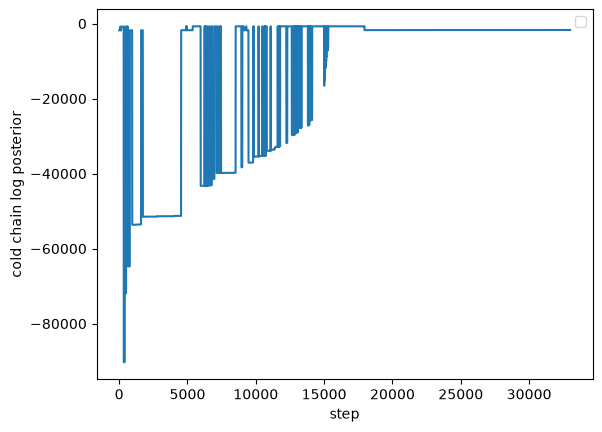

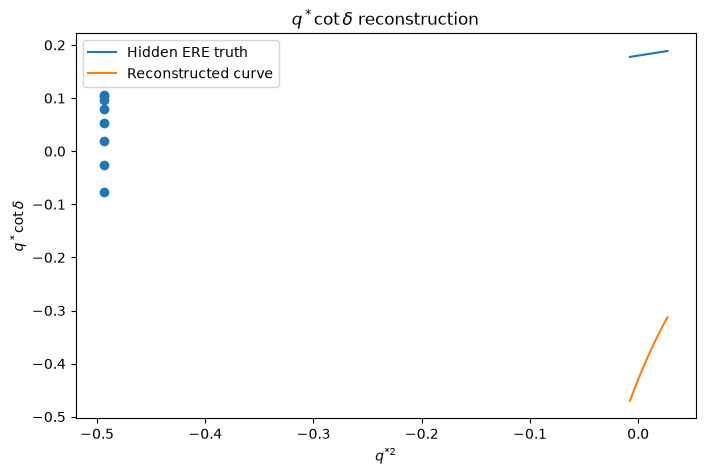

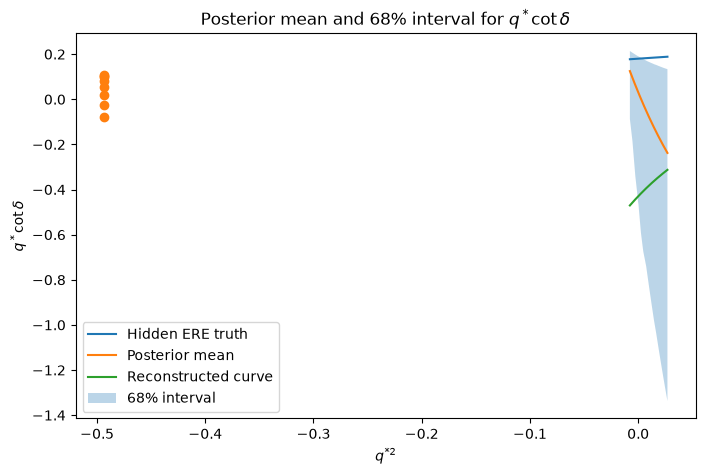

In [34]:
plot_mcmc(observed_cache_dineutron, best_cold_state_cov, cold_log_post_history_cov, samples_cov, data_real)

In [35]:
print(swap_accepts_cov/swap_attempts_cov)

[0.99028571 0.998      0.99542857 0.99857143 1.         0.01714286
 0.02142857 0.04857143 0.04514286]


In [36]:
def inspect_residuals(channel_data, best_state):
    f_values, sigma, length_scale = best_state
    Kinv = Kinv_Grid(Ecm_grid, sigma, length_scale, f_values)

    L = channel_data["L"]
    sector_keys = channel_data["sector_keys"]   # [(Psq, level_index), ...]
    obs = channel_data["obs"]
    cov_inv = channel_data["cov_inv"]
    punit2 = (2 * np.pi / L) ** 2

    # Step 1: how many predicted zeros exist per sector, and where
    needed_Psq = sorted(set(psq for psq, _ in sector_keys))
    pred_by_sector = {}
    for Psq in needed_Psq:
        E_pred_arr = np.sort(find_Zeros_GPR(f_values, sigma, length_scale, L, Psq, Kinv))
        pred_by_sector[Psq] = E_pred_arr
        n_needed = sum(1 for psq, _ in sector_keys if psq == Psq)
        print(f"Psq={Psq}: {len(E_pred_arr)} predicted zero(s) (need {n_needed}) -> {E_pred_arr}")

    # Step 2: build pred the same way log_likelihood does, but keep every value
    pred = np.full_like(obs, np.nan)
    for i, (Psq, level_index) in enumerate(sector_keys):
        E_pred_arr = pred_by_sector[Psq]
        if level_index >= len(E_pred_arr):
            print(f"  level {i} (Psq={Psq}, idx={level_index}): NO matching predicted zero")
            continue
        E_pred = E_pred_arr[level_index]
        pred[i] = ((E_pred / 2) ** 2 - m**2) / punit2

    # Step 3: print obs vs pred side by side
    print(f"\n{'i':>2} {'Psq':>4} {'lvl':>4} {'obs':>14} {'pred':>14} {'delta':>14}")
    for i, (Psq, level_index) in enumerate(sector_keys):
        delta_i = pred[i] - obs[i]
        print(f"{i:2d} {Psq:4d} {level_index:4d} {obs[i]:14.5f} {pred[i]:14.5f} {delta_i:14.5f}")

    delta = pred - obs
    chi_squared = delta @ cov_inv @ delta
    print(f"\nchi^2 = {chi_squared:.3f}")
    return obs, pred, delta


obs_vals, pred_vals, delta_vals = inspect_residuals(observed_cache_dineutron, best_cold_state_cov)

Psq=0: 2 predicted zero(s) (need 2) -> [1.40580091 1.43223305]
Psq=1: 2 predicted zero(s) (need 2) -> [1.41226737 1.43923152]
Psq=2: 1 predicted zero(s) (need 1) -> [1.41918533]
Psq=3: 1 predicted zero(s) (need 1) -> [1.42731058]
Psq=4: 2 predicted zero(s) (need 2) -> [1.40579324 1.43196964]

 i  Psq  lvl            obs           pred          delta
 0    0    0       -0.03629        0.01786        0.05415
 1    0    1        0.91018        1.11235        0.20217
 2    1    0        0.18139        0.28374        0.10235
 3    1    1        1.15789        1.40556        0.24767
 4    2    0        0.38582        0.56953        0.18372
 5    3    0        0.60225        0.90698        0.30473
 6    4    0       -0.03867        0.01755        0.05622
 7    4    1        0.90159        1.10135        0.19976

chi^2 = 534.038


In [37]:
def inspect_frame_dependence(best_state):
    f_values, sigma, length_scale = best_state
    Kinv = Kinv_Grid(Ecm_grid, sigma, length_scale, f_values)

    for Psq, nP in Psq_to_nP.items():
        print(f"\nPsq={Psq}, nP={nP}")

        # 1) is F_by_Psq actually different across frames?
        F_vals = F_by_Psq[(48, Psq)]
        print(f"  F range: [{F_vals.min():.5f}, {F_vals.max():.5f}]")

        # 2) where are the free-particle poles for this frame?
        poles = free_particle_poles_cached(nP, 48, m, E_min, E_max)
        print(f"  free-particle poles in range: {poles}")

        # 3) full quantization curve Q = Re(Kinv + F), and where it actually crosses zero
        #    WITHOUT the pole exclusion, so you can see what's being thrown away
        Q = np.real(Kinv + F_vals)
        sign_changes = np.where(np.diff(np.sign(Q)) != 0)[0]
        raw_crossing_energies = Ecm_grid[sign_changes]
        print(f"  ALL sign changes (before pole exclusion): {raw_crossing_energies}")

        # 4) what find_Zeros_GPR actually returns after exclusion
        kept = find_Zeros_GPR(f_values, sigma, length_scale, 48, Psq, Kinv)
        print(f"  KEPT after pole exclusion: {kept}")


inspect_frame_dependence(best_cold_state_cov)


Psq=0, nP=[0 0 0]
  F range: [-10.17183+0.00182j, 0.73279+0.00182j]
  free-particle poles in range: [1.4053654  1.42954218 1.45331681 1.47670873]
  ALL sign changes (before pole exclusion): [1.40535026 1.40578483 1.42954087 1.43221858]
  KEPT after pole exclusion: [1.40580091 1.43223305]

Psq=1, nP=[0 0 1]
  F range: [-9.26568+0.00203j, 1.00171+0.00203j]
  free-particle poles in range: [1.41139666 1.43547353 1.45877781 1.45915307 1.48209641]
  ALL sign changes (before pole exclusion): [1.41138269 1.41224797 1.43547165 1.43921902]
  KEPT after pole exclusion: [1.41226737 1.43923152]

Psq=2, nP=[0 1 1]
  F range: [-2.26846+0.00221j, 2.76423+0.00130j]
  free-particle poles in range: [1.41730256 1.41750534 1.44128558 1.44147851 1.46432336 1.4648756
 1.48756433 1.48809135]
  ALL sign changes (before pole exclusion): [1.41729149 1.41738944 1.41748738 1.41917086 1.4412817  1.44137801
 1.44147432]
  KEPT after pole exclusion: [1.41918533]

Psq=3, nP=[1 1 1]
  F range: [-0.70326+0.00158j, 12.8

In [ ]:
def inspect_near_poles(Psq, best_state, pad=0.003, n=5000):
    f_values, sigma, length_scale = best_state
    poles = free_particle_poles_cached(Psq_to_nP[Psq], 48, m, E_min, E_max)
    # focus on the tightest pole cluster
    poles_sorted = np.sort(poles)
    center = poles_sorted[np.argmin(np.diff(poles_sorted))] if len(poles_sorted) > 1 else poles_sorted[0]

    fine_grid = np.linspace(center - pad, center + pad, n)
    Kinv = Kinv_Grid(fine_grid, sigma, length_scale, f_values)
    F_vals = np.array([F_function(E, Psq_to_nP[Psq], alpha, 48) for E in fine_grid])
    Q = np.real(Kinv + F_vals)

    plt.figure(figsize=(9,5))
    plt.axhline(0, color="gray", linewidth=0.8)
    plt.plot(fine_grid, Q)
    for p in poles:
        if center - pad <= p <= center + pad:
            plt.axvline(p, color="red", linestyle="--", alpha=0.6)
    plt.ylim(-3, 3)
    plt.xlabel("Ecm")
    plt.ylabel("Q")
    plt.title(f"Zoomed near-pole region, Psq={Psq}")
    plt.show()

inspect_near_poles(2, best_cold_state_cov)
inspect_near_poles(3, best_cold_state_cov)